# Predictive Modelling of Proteomics using a Transformer Model

## Task Type and Model Decision
I selected a Transformer model because the multi-head attention can learn different types of relationships between omics data features and capturing various correlations that might exist. The self-attention mechanism allows the model to identify important feature interactions, which I think are important in multi-omics data integration. While VAEs would also be suitable, particularly for handling noise and missing values, the potential complex interactions between omics data features made Transformers my preferred choice.

## Data
The aim is to use multiple input omics datasets to predict proteomics data. Input omics data was selected by iteratively testing combinations to determine which best predicted proteomics. This indicated that transcriptomics data only as the optimal input combination for proteomics prediction.

## Plan
The approach follows a systematic comparison between a baseline MLP model and the Transformer architecture:

#### In EMBL_transformer_explore.ipynb
1. [Inspect data](#inspect-data);
2. [Create a simple MLP model](#baseline-mlp) as a baseline;
3. [Develop Transformer models](#transformer-models) with different fusion strategies and activation functions;
4. [Perform hyperparameter tuning](#hyperparameter-tuning);
5. [Conduct progressive input omics selection](#omics-selection);
6. [Create comprehensive loop](#evaluation-loop) to iterate through steps 3-5, obtaining metrics to determine the best Transformer model for comparison with the baseline MLP;

#### In EMBL_transformer_best_model.ipynb
7. [Select best-performing model](#best-performing);
8. [Analyse best-predicted proteomic features](#feature-analysis);


## Results
- The [baseline MLP model](#results-MLP) performed quite well already, with an R^2 ~0.83, an RMSE ~0.69, and prediction errors that are roughly Normally distributed.
- The best [Transformer model](#results-transformer) demonstrated that using transcriptomics data only as input omics data performed best, with R^2 ~0.83. However, rerunning the algorithm shows some variability in the best performing hyperparameters, such as fusion method selected. In addition, the Transformer model does not significantly outperform the baseline MLP model. Moving forward, cross-validation and improved data handling (e.g. outlier handling) would be worth exploring. 
- The results of the [feature analysis](#results-feature-analysis) showed significant correlation values >0.5 between the predicted and actual values. However, the R^2 values are low, indicating that while the general trends in protein expression are captured, the model does not accurately predict the exact values. 

## Future Work
Given more time, I would implement:

1. Cross-validation for more robust model evaluation;
2. Enhanced data handling, particularly for outliers. Despite the task stating the data was "processed and cleaned, so you can use them directly" I encountered outliers that might affect results. Going forward, I would address these outliers prior to modelling;
3. Development of ensemble methods to potentially improve prediction accuracy.



In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# for using VSCode
import sys
from pathlib import Path

# Add the parent directory of transformer_multiomics to sys.path
sys.path.append(str(Path.cwd().parent))

In [3]:
from transformer_multiomics.config import DATA_PATH, MODEL_PATH, RESULT_PATH
from transformer_multiomics.data.data_loader import ensure_directories_exist, load_datasets
from transformer_multiomics.data.data_preparation import prepare_data_loaders
from transformer_multiomics.models.mlp import MultiOmicsMLP
from transformer_multiomics.training.evaluater import (
    analyse_feature_level_performance,
    evaluate_model,
    summarise_results,
)
from transformer_multiomics.training.optimizing import progressive_omics_selection
from transformer_multiomics.training.trainer import train_model
from transformer_multiomics.utils.plots import plot_error_distribution, plot_loss_curves

In [4]:
# CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# Ensure directories exist
ensure_directories_exist(MODEL_PATH, RESULT_PATH, DATA_PATH)

# Load datasets
datasets = load_datasets()
print("Available datasets:", datasets.keys())

Directory exists: /home/jantine/Projects/transformer_multiomics/models
Directory exists: /home/jantine/Projects/transformer_multiomics/results
Directory exists: /home/jantine/Projects/transformer_multiomics/datasets
Available datasets: dict_keys(['methylation', 'metabolomics', 'proteomics', 'transcriptomics', 'cnv'])


# MLP Base Model <a id="baseline-mlp"></a> 
The idea is to start with a simple MLP base model with a few hidden layers to serve as a benchmark for the Transformer. This base model will also only use one type of input omics data, i.e. transcriptomics, to predict the proteomics data.

In [6]:
input_datasets = ["transcriptomics", "methylation", "metabolomics", "cnv"]
target_dataset = "proteomics"

train_loader, val_loader, test_loader, input_dims_dict, output_dim = prepare_data_loaders(
    omics_set=input_datasets, datasets=datasets, target_dataset=target_dataset, batch_size=32, test_size=0.2
)

In [7]:
# Initialize model with multi-omics input dims
mlp_model = MultiOmicsMLP(input_dims_dict=input_dims_dict, output_dim=output_dim, hidden_dims=[256, 128, 64]).to(device)

# Loss function and optimiser
mlp_criterion = nn.MSELoss()
learning_rate = 0.001
weight_decay = 0
mlp_optimiser = optim.Adam(mlp_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Early stopping setup
patience = 15
epochs = 100

mlp_model = MultiOmicsMLP(input_dims_dict=input_dims_dict, output_dim=output_dim, hidden_dims=[256, 128, 64]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=0)

trained_model, train_losses, test_losses, best_loss, early_stop_epoch = train_model(
    model=mlp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    patience=patience,
    model_name="multiomics_mlp",
    save_path=MODEL_PATH,
    return_attention_weights=False,
)

Starting training for multiomics_mlp...


Epoch 1/100 | Train Loss: 20.1424 | Test Loss: 17.2707 | Early Stopping: 0/15


Epoch 11/100 | Train Loss: 4.7768 | Test Loss: 3.9293 | Early Stopping: 0/15


Epoch 21/100 | Train Loss: 0.6184 | Test Loss: 0.6219 | Early Stopping: 0/15


Epoch 31/100 | Train Loss: 0.4614 | Test Loss: 0.4945 | Early Stopping: 0/15


...

Epoch 61/100 | Train Loss: 0.4335 | Test Loss: 0.4753 | Early Stopping: 1/15


Epoch 71/100 | Train Loss: 0.4368 | Test Loss: 0.4724 | Early Stopping: 3/15


Epoch 81/100 | Train Loss: 0.4322 | Test Loss: 0.4719 | Early Stopping: 8/15


Epoch 91/100 | Train Loss: 0.4292 | Test Loss: 0.4715 | Early Stopping: 3/15


Epoch 100/100 | Train Loss: 0.4390 | Test Loss: 0.4753 | Early Stopping: 12/15
Best model saved to /home/jantine/Projects/transformer_multiomics/models/best_multiomics_mlp_model.pt


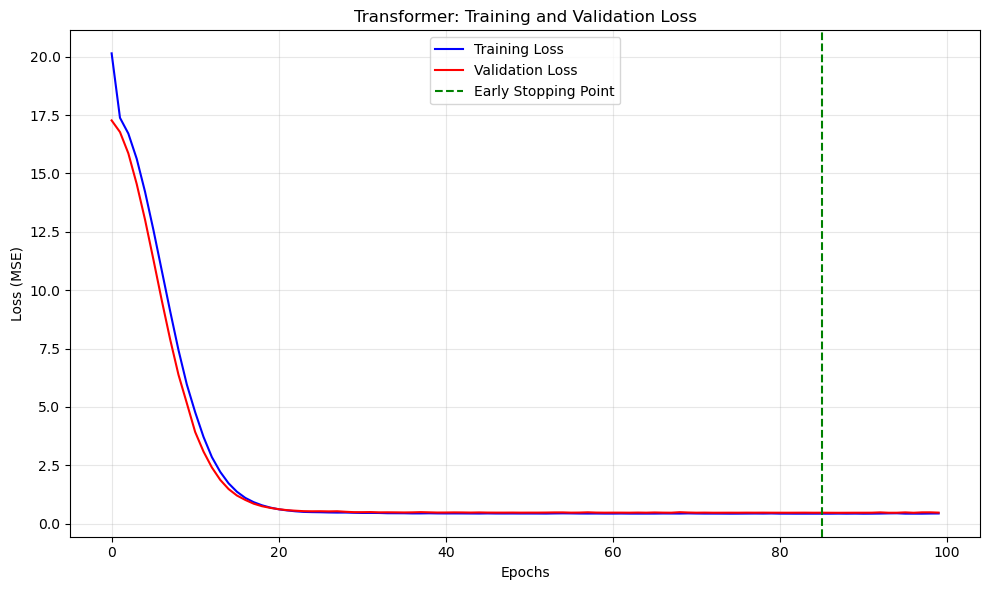

In [8]:
# Plot training and validation loss curves
early_stopping_epoch = len(test_losses) - patience
plot_loss_curves(
    train_losses,
    test_losses,
    early_stopping_epoch=early_stopping_epoch,
    title="Transformer: Training and Validation Loss",
)

In [9]:
# Evaluate model performance
metrics_mlp = evaluate_model(mlp_model, test_loader, device, is_transformer=False, model_name="MLP")

Evaluating MLP: 100%|██████████| 2/2 [00:00<00:00, 371.10it/s]

MLP Performance:
R-squared (R²): 0.8403
Root Mean Squared Error (RMSE): 0.6894
Mean Absolute Error (MAE): 0.5031
Explained Variance Score: 0.8419


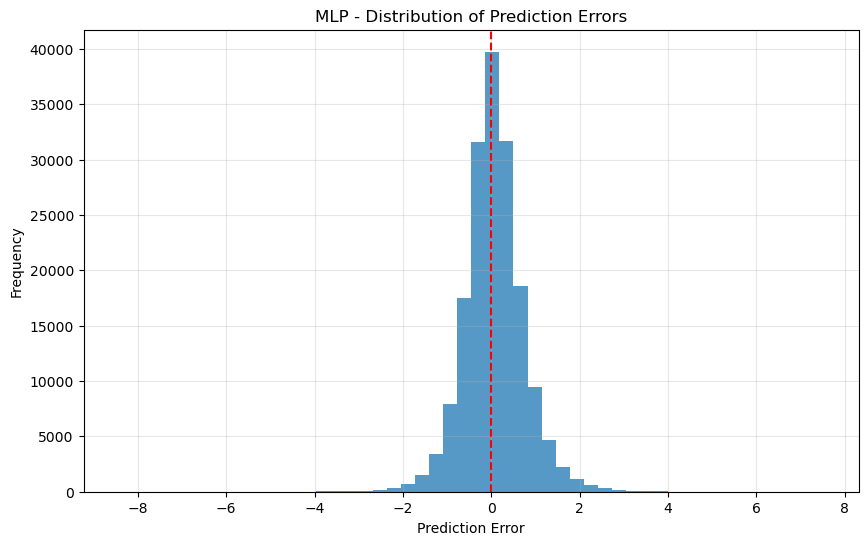

In [10]:
# Plot error distribution
all_predictions = metrics_mlp["predictions"]
all_targets = metrics_mlp["targets"]

plot_error_distribution(all_predictions, all_targets, model_name="MLP")

# Baseline MLP Results <a id="results-MLP"></a>

The MLP is performing quite well already, with R^2 of ~0.83 and the error distribution normally distributed. The errors look Normally distributed, so the MLP is already performing well without systematically overestimating/underestimating the target values. 

# Transformer <a id="transformer-models"></a> 

This part is the development of the Transformer model. The Transformer model is designed so that it can be used to iteratively scan through different combinations of input omics data, fusion strategies, activation function (only ReLU and GeLU, as I'm working with PyTorch), and for hyperparameter optimisation.

## Hyperparameter Tuning <a id="hyperparameter-tuning"></a> 

[I 2025-07-16 16:56:50,208] A new study created in memory with name: no-name-f4c7f2d3-507d-4c02-beb7-dc99ca7db4e7



Optimising hyperparameters for omics set: ['transcriptomics']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 16:56:55,228] Trial 0 finished with value: 0.3827507793903351 and parameters: {'num_heads': 16, 'num_layers': 6, 'hidden_dim': 320, 'dropout_rate': 0.0, 'learning_rate': 0.0008141052856325478, 'weight_decay': 0.00016649563641918632, 'fusion_method': 'cross_attention', 'activation_function': 'gelu'}. Best is trial 0 with value: 0.3827507793903351.
[I 2025-07-16 16:56:57,380] Trial 1 finished with value: 15.12468433380127 and parameters: {'num_heads': 16, 'num_layers': 5, 'hidden_dim': 384, 'dropout_rate': 0.1, 'learning_rate': 1.6107553289629702e-05, 'weight_decay': 3.7025816547598544e-05, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 0.3827507793903351.
[I 2025-07-16 16:56:59,988] 


Best hyperparameters:
  num_heads: 16
  num_layers: 6
  hidden_dim: 320
  dropout_rate: 0.0
  learning_rate: 0.0008141052856325478
  weight_decay: 0.00016649563641918632
  fusion_method: cross_attention
  activation_function: gelu

Best validation loss: 0.382751

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics']
Starting training for best_model_transcriptomics...


Epoch 1/50 | Train Loss: 16.7824 | Test Loss: 14.7804 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 1.0449 | Test Loss: 0.8671 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4710 | Test Loss: 0.3924 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4580 | Test Loss: 0.3820 | Early Stopping: 2/10



Early stopping at epoch 39


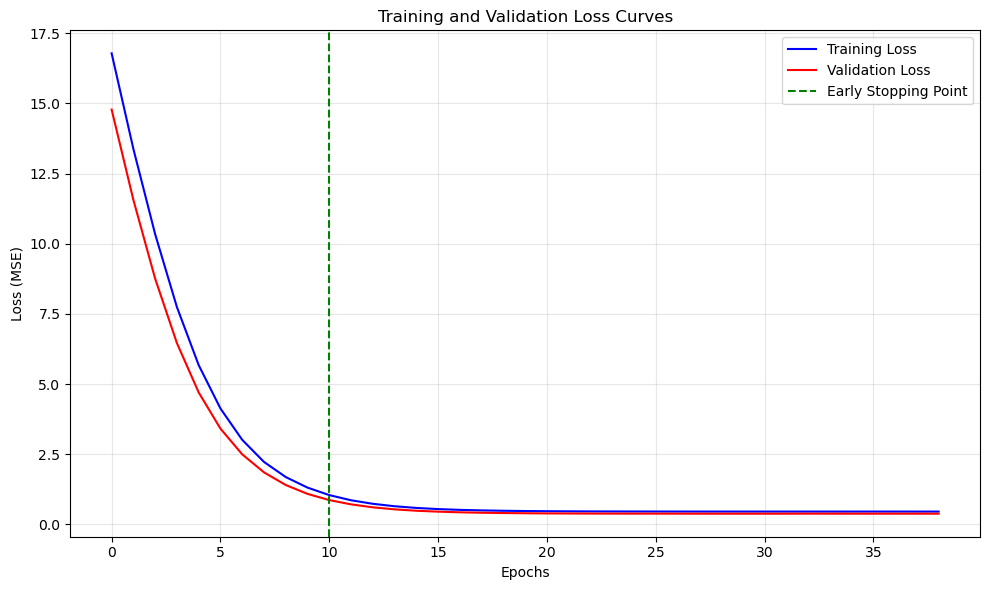


Baseline with ['transcriptomics']: R² = 0.8378


,Step,Current Set,R²,RMSE
0,0,transcriptomics,0.837844,0.694721


[I 2025-07-16 16:57:54,129] A new study created in memory with name: no-name-084847c8-d975-4119-a34f-4242c0a915e8



Testing omics set: ['transcriptomics', 'methylation']

Optimising hyperparameters for omics set: ['transcriptomics', 'methylation']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 16:58:00,248] Trial 0 finished with value: 3.745147228240967 and parameters: {'num_heads': 8, 'num_layers': 6, 'hidden_dim': 384, 'dropout_rate': 0.1, 'learning_rate': 0.00015028167673763785, 'weight_decay': 1.562211452894812e-05, 'fusion_method': 'cross_attention', 'activation_function': 'relu'}. Best is trial 0 with value: 3.745147228240967.
[I 2025-07-16 16:58:05,355] Trial 1 finished with value: 16.89090919494629 and parameters: {'num_heads': 16, 'num_layers': 5, 'hidden_dim': 256, 'dropout_rate': 0.5, 'learning_rate': 1.2249833995448067e-05, 'weight_decay': 2.3970875869789515e-06, 'fusion_method': 'gated', 'activation_function': 'gelu'}. Best is trial 0 with value: 3.745147228240967.
[I 2025-07-16 16:58:08,505] Tri

...

Epoch 1/50 | Train Loss: 15.5516 | Test Loss: 11.8223 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5802 | Test Loss: 0.4507 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4861 | Test Loss: 0.3819 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4885 | Test Loss: 0.3819 | Early Stopping: 2/10



Early stopping at epoch 39


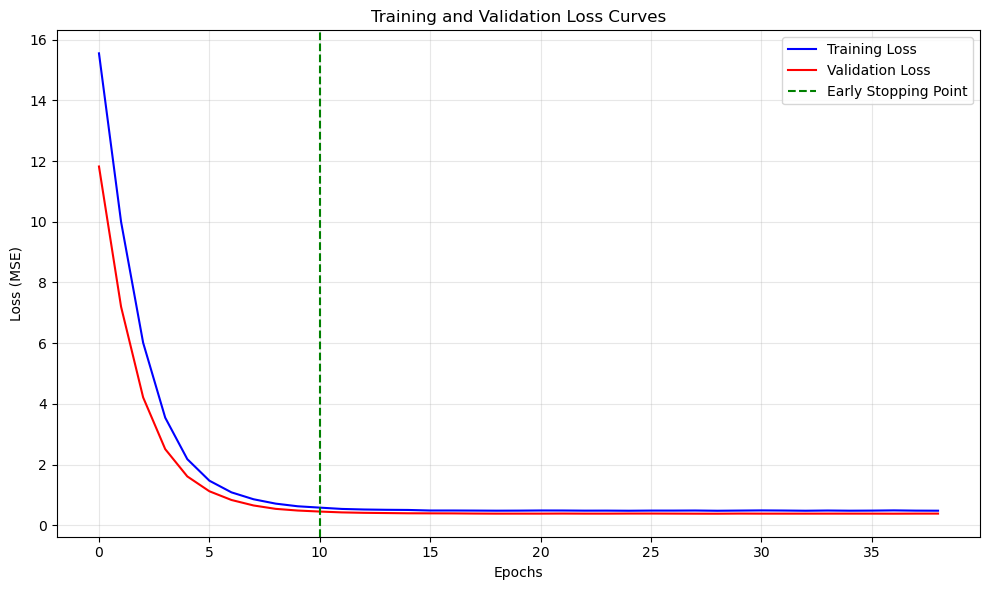

[I 2025-07-16 16:59:20,610] A new study created in memory with name: no-name-c5b6d6bb-9759-454b-94e4-714ebcd87333


All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Adding methylation → R² = 0.8376 (Δ = -0.0003)

Testing omics set: ['transcriptomics', 'metabolomics']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 16:59:24,725] Trial 0 finished with value: 2.5839428901672363 and parameters: {'num_heads': 16, 'num_layers': 5, 'hidden_dim': 192, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0003510618604268779, 'weight_decay': 5.790191699193525e-05, 'fusion_method': 'hierarchical', 'activation_function': 'gelu'}. Best is trial 0 with value: 2.5839428901672363.
[I 2025-07-16 16:59:29,781] Trial 1 finished with value: 0.5786007642745972 and parameters: {'num_heads': 4, 'num_layers': 6, 'hidden_dim': 448, 'dropout_rate': 0.1, 'learning_rate': 0.00027415610160674153, 'weight_decay': 1.5233456188157118e-06, 'fusion_method': 'cross_attention', 'activation_function': 'gelu'}. Best is trial 1 with value: 0.5786007642745972.
[I 20


Best hyperparameters:
  num_heads: 4
  num_layers: 2
  hidden_dim: 512
  dropout_rate: 0.4
  learning_rate: 0.0009546554032598812
  weight_decay: 0.00024285441931688238
  fusion_method: late
  activation_function: relu

Best validation loss: 0.380408

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics']
Starting training for best_model_transcriptomics_metabolomics...


Epoch 1/50 | Train Loss: 15.5696 | Test Loss: 11.6632 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5929 | Test Loss: 0.4462 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.5101 | Test Loss: 0.3820 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.5141 | Test Loss: 0.3798 | Early Stopping: 0/10


Epoch 41/50 | Train Loss: 0.5031 | Test Loss: 0.3830 | Early Stopping: 10/10

Early stopping at epoch 41


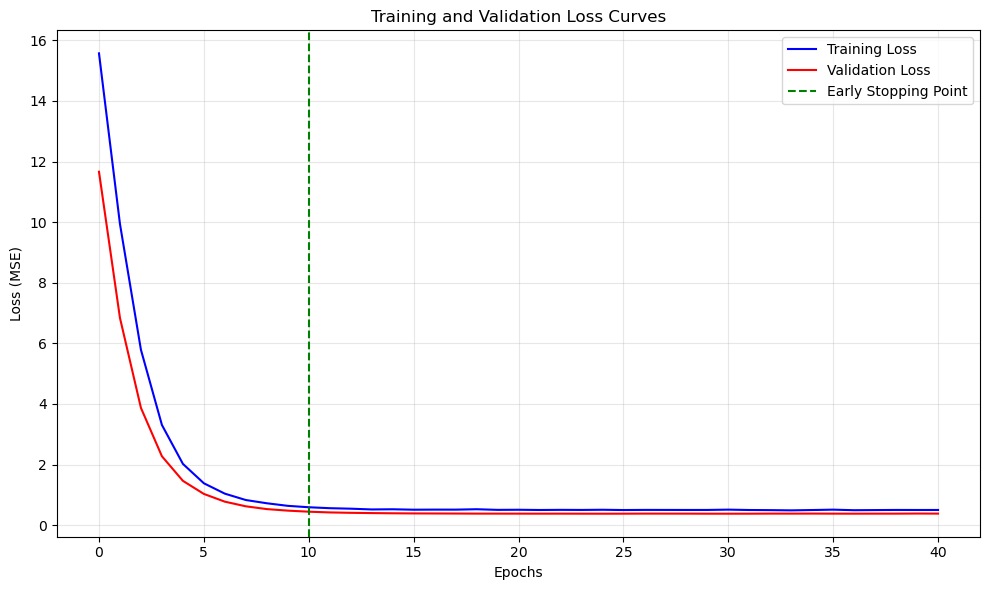

[I 2025-07-16 17:00:38,236] A new study created in memory with name: no-name-1b985286-1da7-44ca-b957-a8ae49fb6f59


All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Adding metabolomics → R² = 0.8375 (Δ = -0.0004)

Testing omics set: ['transcriptomics', 'cnv']

Optimising hyperparameters for omics set: ['transcriptomics', 'cnv']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 17:00:43,402] Trial 0 finished with value: 11.535118103027344 and parameters: {'num_heads': 16, 'num_layers': 4, 'hidden_dim': 384, 'dropout_rate': 0.0, 'learning_rate': 4.575574969974582e-05, 'weight_decay': 2.1619210628992903e-05, 'fusion_method': 'hierarchical', 'activation_function': 'relu'}. Best is trial 0 with value: 11.535118103027344.
[I 2025-07-16 17:00:47,664] Trial 1 finished with value: 6.771081447601318 and parameters: {'num_heads': 8, 'num_layers': 2, 'hidden_dim': 128, 'dropout_rate': 0.4, 'learning_rate': 0.0002960218925406424, 'weight_decay': 1.984118011258845e-05, 'fusion_method': 'weighted', 'activation_function': 'gelu'}. Best is trial 1 with value: 6.771081447601318.
[I 2025-07-16 17:00:51,256] Tri


Best hyperparameters:
  num_heads: 4
  num_layers: 5
  hidden_dim: 512
  dropout_rate: 0.4
  learning_rate: 0.0009843535453150467
  weight_decay: 0.0009098715223461142
  fusion_method: gated
  activation_function: relu

Best validation loss: 0.379820

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'cnv']
Starting training for best_model_transcriptomics_cnv...


Epoch 1/50 | Train Loss: 15.4766 | Test Loss: 11.4819 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5779 | Test Loss: 0.4408 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4982 | Test Loss: 0.3819 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4937 | Test Loss: 0.3809 | Early Stopping: 3/10



Early stopping at epoch 38


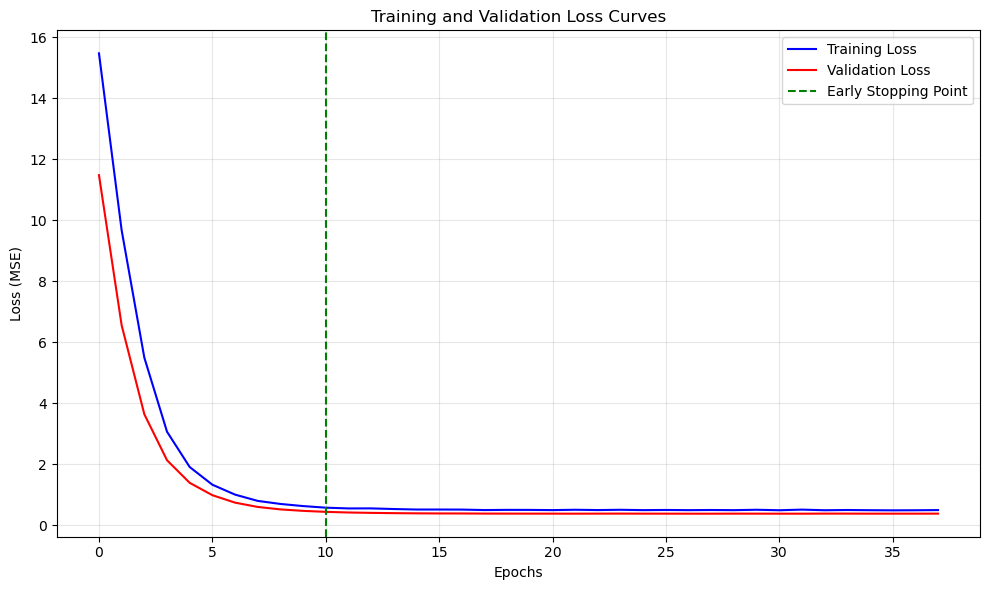

All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics'), ('transcriptomics', 'cnv')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'cnv'), Contains 'Hyperparameters': True
Adding cnv → R² = 0.8372 (Δ = -0.0006)


,Added Omics,Test Set,R²,RMSE,Improvement
0,methylation,transcriptomics+methylation,0.837555,0.695340,-0.000289
1,metabolomics,transcriptomics+metabolomics,0.837475,0.695511,-0.000369
2,cnv,transcriptomics+cnv,0.837201,0.696097,-0.000643



No further improvement. Best set: ['transcriptomics'], R²: 0.8378


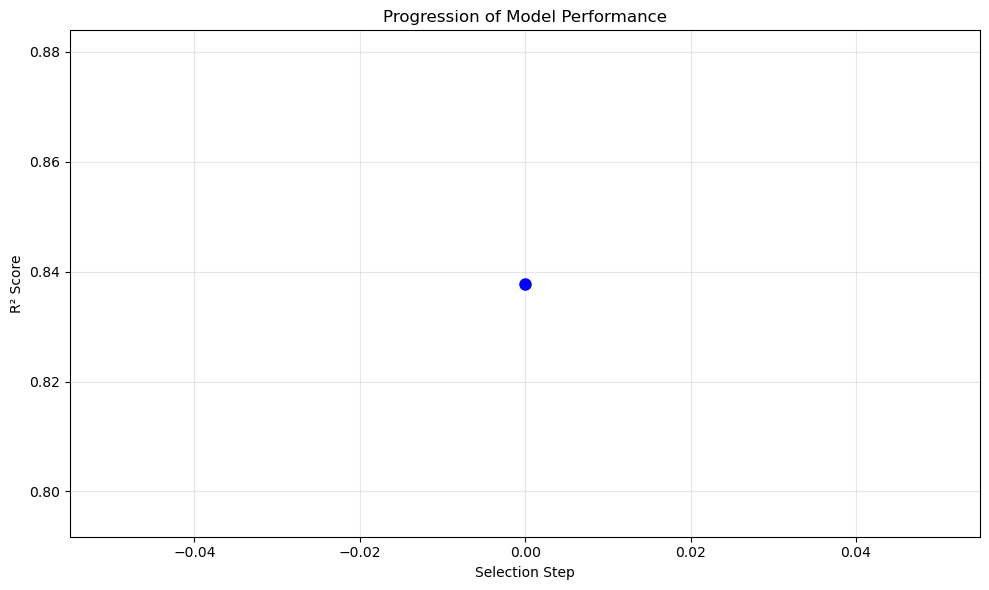



===== SUMMARY OF ALL COMBINATIONS =====
Omics Set                      R²         RMSE       MAE        EVS        Fusion          Activation
------------------------------------------------------------------------------------------
transcriptomics                0.8378     0.6947     0.5056     0.8381     cross_attention gelu      
transcriptomics+methylation    0.8376     0.6953     0.5060     0.8379     weighted        relu      
transcriptomics+metabolomics   0.8375     0.6955     0.5057     0.8381     late            relu      
transcriptomics+cnv            0.8372     0.6961     0.5063     0.8377     gated           relu      


<Figure size 1200x800 with 0 Axes>

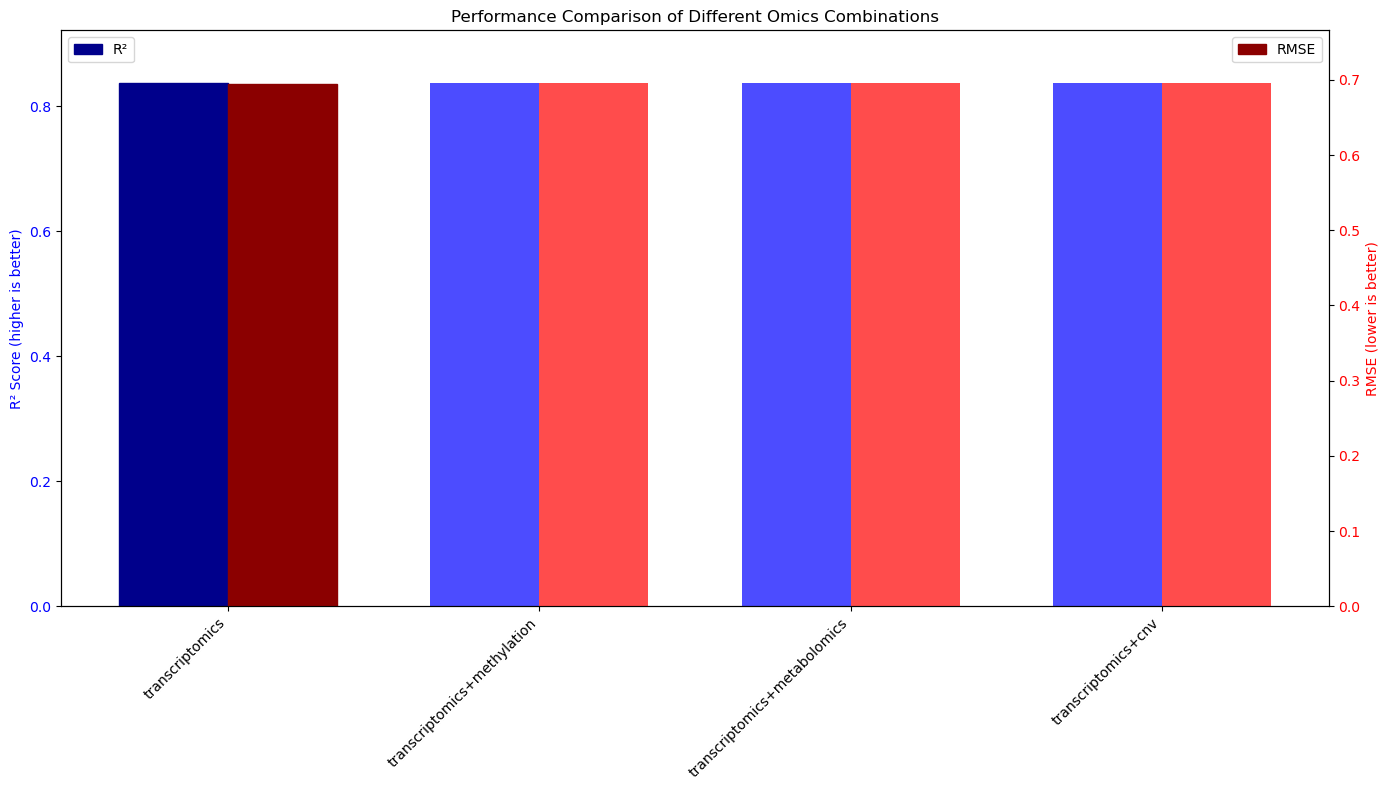

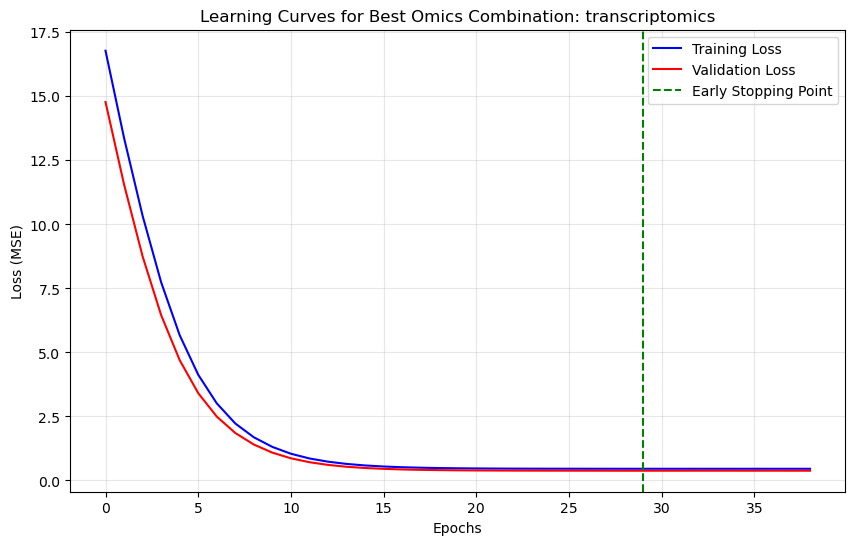

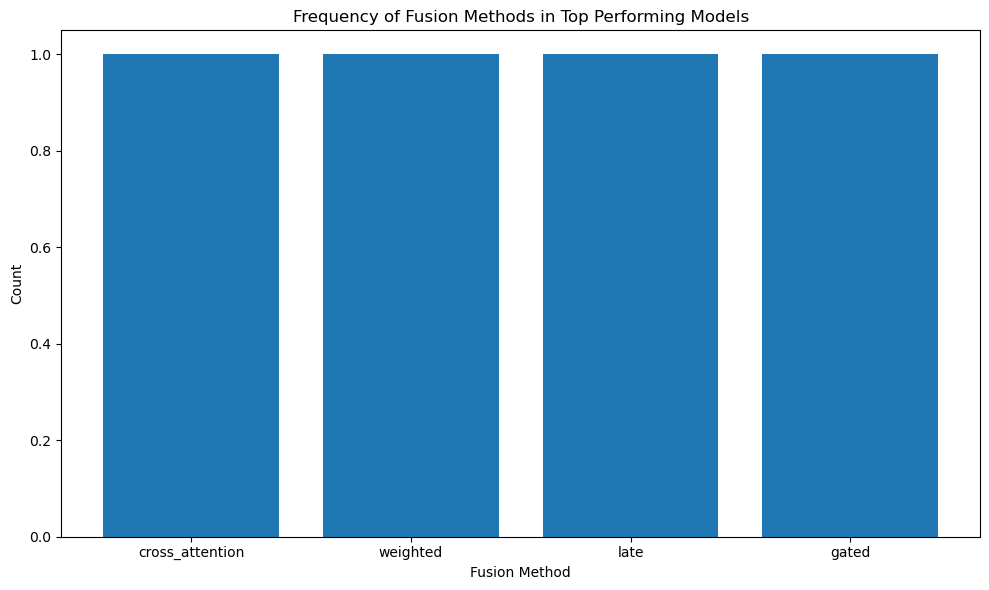


Best omics combination found: transcriptomics
Best R^2 score: 0.8378
Best model's hyperparameters saved successfully.


In [11]:
# All omics list
all_omics_types = ["methylation", "metabolomics", "transcriptomics", "cnv"]

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Run the progressive selection process
all_results, best_omics_set, progress_df = progressive_omics_selection(
    all_omics_types, datasets, n_trials=20, device=device
)

# Summarise the results
summary = summarise_results(all_results, best_omics_set)

# Save the progress dataframe
progress_df.to_csv(RESULT_PATH / "progressive_selection_results.csv", index=False)

# Print the best combination
print(f"\nBest omics combination found: {'+'.join(best_omics_set)}")
print(f"Best R^2 score: {all_results[tuple(best_omics_set)]['R2']:.4f}")


# Save the best model's hyperparameters
if "Hyperparameters" in all_results[tuple(best_omics_set)]:
    best_params = all_results[tuple(best_omics_set)]["Hyperparameters"]
    best_params_df = pd.DataFrame([best_params])
    best_params_df.to_csv(RESULT_PATH / "best_model_hyperparameters.csv", index=False)
    print("Best model's hyperparameters saved successfully.")
else:
    print("Error: 'Hyperparameters' key is missing for the best omics set.")
    best_params = {}
    print("Skipping saving hyperparameters due to missing data.")

# best_omics_set, best_params

# Results Transformer Models <a id="results-transformer"></a>

- Best omics combination found: transcriptomics only
- Best R² score: 0.8379

(['transcriptomics'],
 {'num_heads': 4,
  'num_layers': 6,
  'hidden_dim': 384,
  'dropout_rate': 0.1,
  'learning_rate': 0.0009052341259832195,
  'weight_decay': 1.1016969061267455e-06,
  'fusion_method': 'gated',
  'activation_function': 'relu'})


## Observations
Although gated fusion method gave the best R^2 score, cross-attention was the most frequently occuring fusion method in top performing models. Perhaps for future work, after cross-validation, dealing with outliers, and especially when the data amount grows, the cross-attention method could be the better performing one.

# Feature Analysis <a id="feature-analysis"></a>

NOTE: this part is also in the EMBL_transformer_best_model.ipynb

Look at best predicting proteomic features.


Analysing feature-level performance...

--------------------------------------------------------------------------------
Analysing feature-level performance for best model: ['transcriptomics']
--------------------------------------------------------------------------------


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Top 10 best predicted features:


/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:260: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = pearsonr(y_true, y_pred)
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:260: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = pearsonr(y_true, y_pred)
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:260: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = pearsonr(y_true, y_pred)
/home/jantine/Projects/transformer_multiomics/transformer_multiomics/training/evaluater.py:260: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, p_value = p

,Feature,R2,RMSE,MAE,Correlation,P_value
755,CLIP1,0.000132,0.576946,0.480866,0.653590,2.070308e-05
52,ACBD6,0.000084,0.446194,0.384436,0.556402,5.187347e-04
69,ACSL4,0.000079,0.638582,0.527312,0.581633,2.477390e-04
4178,STIM1,0.000057,0.702907,0.550894,0.726101,7.938081e-07
3841,SEC11A,0.000056,0.774597,0.643306,0.621558,6.742846e-05
1354,ETFB,0.000053,1.076005,0.865602,0.728731,6.919353e-07
851,COQ8B,0.000050,0.738215,0.593844,0.482246,3.349485e-03
4337,THOC5,0.000049,0.309062,0.237848,0.343942,4.306450e-02
3106,PLK1,0.000044,0.310086,0.233966,0.192703,2.673972e-01
1605,GMDS,0.000044,0.873705,0.719079,0.362863,3.216239e-02



Bottom 10 worst predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
4089,SPATS2L,-0.259842,0.809978,0.671690,-0.357000,0.035268
3308,PRXL2A,-0.265526,0.692222,0.542813,-0.501567,0.002144
3360,PSPH,-0.270234,0.925469,0.673397,-0.483683,0.003243
907,CRYZL1,-0.295283,0.397299,0.310147,0.296526,0.083683
2223,LYRM7,-0.301605,0.503130,0.404498,0.096981,0.579429
1830,HNRNPF,-0.326536,0.419287,0.353394,0.121575,0.486608
34,ABRACL,-0.341925,0.798719,0.618502,0.225058,0.193650
1169,DUS2,-0.343608,0.353843,0.279395,-0.329782,0.053031
3587,RHOB,-0.384410,0.656932,0.546308,0.246621,0.153231
410,BAP18,-0.397554,0.646640,0.460743,0.286747,0.094902


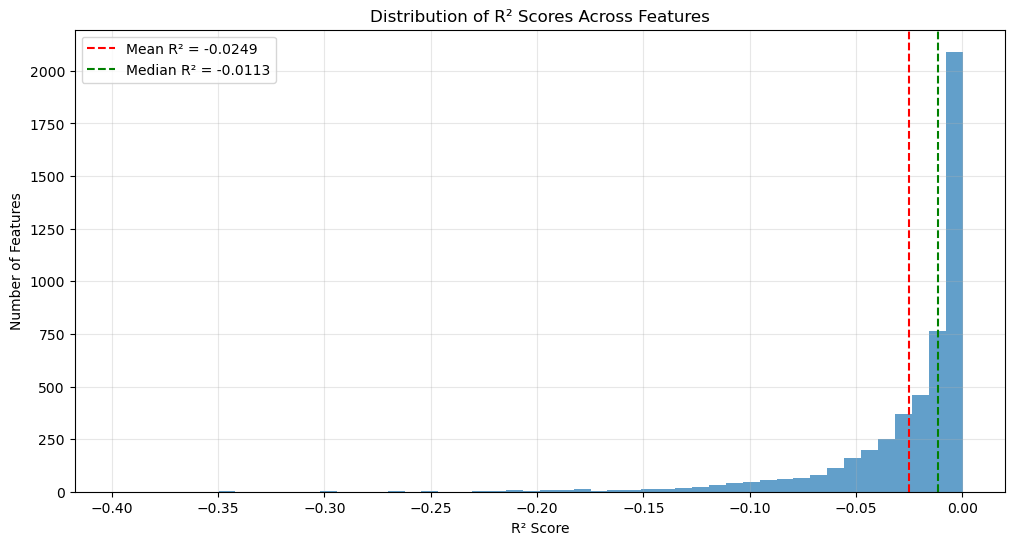

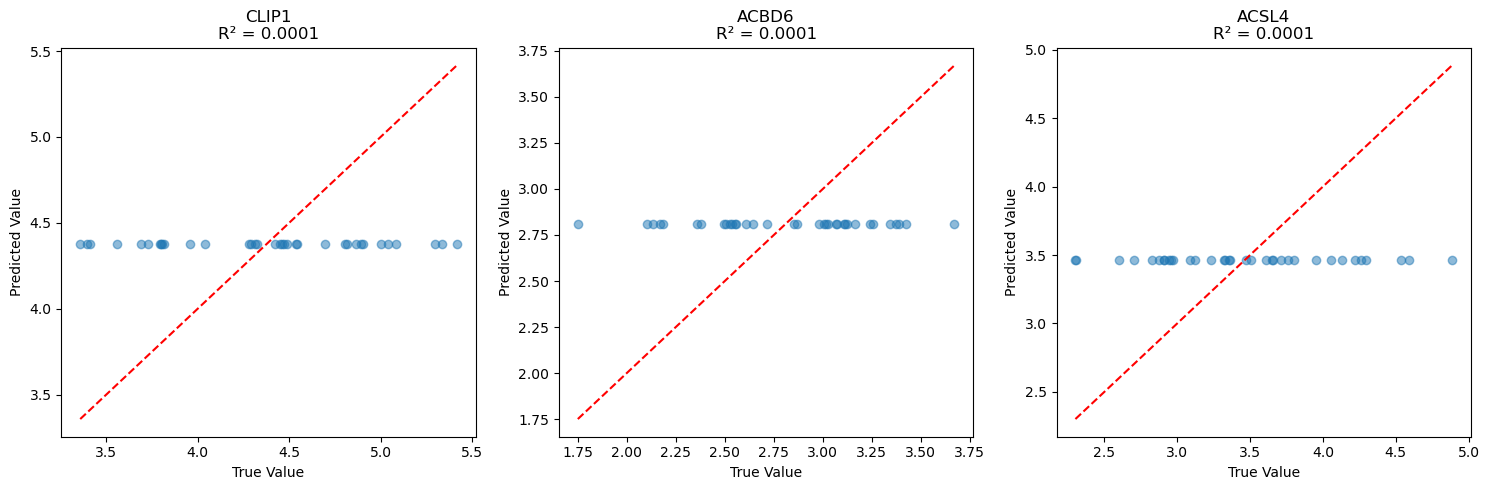

In [12]:
# Feature Analysis
print("\nAnalysing feature-level performance...")
feature_performance = analyse_feature_level_performance(best_omics_set, best_params, datasets, device)

# Best Predicting Protein Features <a id="results-feature-analysis"></a>

The results that the best predicting proteomic features actually have very low R^2 values, which indicates weak prediction performance and not a lot of variability is explained. The correlation values between the predicted and actual values >0.5 with significant p-values, so the model seems to capture some meaningful relationship between input omics data and protein expression, but not strongly. 


The disconnect between the correlation values and the very low R^2 values suggests that while the model is capturing some general trends in protein expression (hence the correlations), it's not accurately predicting the exact values (hence the poor R^2 values). This could be due to scaling issues in the predictions or systematic biases that the model hasn't learned to correct.


The RMSE values are consistently higher than MAE, suggesting some (larger) errors in the predictions. This because RMSE is more sensitive to outliers (quadratic penalty).